# 01. Setup dan Eksplorasi Dataset FashionMNIST

In [1]:
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision
from torchvision import datasets, transforms

In [2]:
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def get_project_root():
    cwd = Path.cwd().resolve()
    if cwd.name.lower() == "notebooks":
        return cwd.parent
    return cwd

PROJECT_ROOT = get_project_root()
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
FEATURES_DIR = RESULTS_DIR / "features"

for path in [DATA_DIR, MODELS_DIR, RESULTS_DIR, FIGURES_DIR, FEATURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: D:\Code\PCA_vs_Autoencoder_FashionMNIST_Project\PCA_vs_Autoencoder_FashionMNIST


In [3]:
CONFIG = {
    "random_seed": 42,
    "batch_size": 128,
    "input_dim": 784,
    "latent_dim": 32,
    "visualization_subset": 2000,
    "pca_train_subset": 10000,
}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG["random_seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Python version     :", sys.version.split()[0])
print("PyTorch version    :", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA tersedia      :", torch.cuda.is_available())
print("Device digunakan   :", device)
if torch.cuda.is_available():
    print("GPU terdeteksi     :", torch.cuda.get_device_name(0))

Python version     : 3.11.5
PyTorch version    : 2.12.0+cu126
Torchvision version: 0.27.0+cu126
CUDA tersedia      : True
Device digunakan   : cuda
GPU terdeteksi     : NVIDIA GeForce RTX 3050 Laptop GPU


In [4]:
transform = transforms.ToTensor()
train_dataset = datasets.FashionMNIST(root=DATA_DIR, train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root=DATA_DIR, train=False, download=True, transform=transform)
print("Dataset FashionMNIST berhasil dimuat.")
print("Jumlah data train:", len(train_dataset))
print("Jumlah data test :", len(test_dataset))

100.0%
100.0%
100.0%
100.0%

Dataset FashionMNIST berhasil dimuat.
Jumlah data train: 60000
Jumlah data test : 10000


In [5]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

summary_df = pd.DataFrame([{
    "Dataset": "FashionMNIST",
    "Train Size": len(train_dataset),
    "Test Size": len(test_dataset),
    "Image Size": "28 x 28",
    "Input Dimension": 784,
    "Classes": 10
}])
display(summary_df)
print("Daftar kelas FashionMNIST:")
for idx, name in enumerate(class_names):
    print(f"{idx}: {name}")

,Dataset,Train Size,Test Size,Image Size,Input Dimension,Classes
0,FashionMNIST,60000,10000,28 x 28,784,10


Daftar kelas FashionMNIST:
0: T-shirt/top
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot


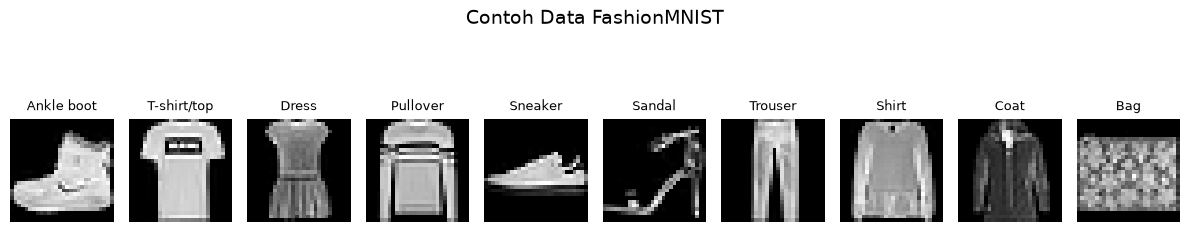

Gambar sampel disimpan ke: D:\Code\PCA_vs_Autoencoder_FashionMNIST_Project\PCA_vs_Autoencoder_FashionMNIST\results\figures\fashionmnist_samples.png


In [6]:
def show_sample_images(dataset, class_names, n=10):
    plt.figure(figsize=(12, 3))
    shown_labels = set()
    selected_indices = []
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        if label not in shown_labels:
            shown_labels.add(label)
            selected_indices.append(idx)
        if len(selected_indices) == n:
            break
    for i, idx in enumerate(selected_indices):
        image, label = dataset[idx]
        plt.subplot(1, n, i + 1)
        plt.imshow(image.squeeze(), cmap="gray")
        plt.title(class_names[label], fontsize=9)
        plt.axis("off")
    plt.suptitle("Contoh Data FashionMNIST", fontsize=14)
    plt.tight_layout()
    output_path = FIGURES_DIR / "fashionmnist_samples.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Gambar sampel disimpan ke:", output_path)

show_sample_images(train_dataset, class_names)

In [7]:
sample_image, sample_label = train_dataset[0]
flattened = sample_image.view(-1)
print("Shape citra asli      :", sample_image.shape)
print("Label                 :", sample_label, "-", class_names[sample_label])
print("Shape setelah flatten :", flattened.shape)
print("Jumlah fitur          :", flattened.numel())
print("Rentang nilai pixel   :", float(flattened.min()), "hingga", float(flattened.max()))

Shape citra asli      : torch.Size([1, 28, 28])
Label                 : 9 - Ankle boot
Shape setelah flatten : torch.Size([784])
Jumlah fitur          : 784
Rentang nilai pixel   : 0.0 hingga 1.0
